In [17]:
import pandas as pd
import numpy as np
from arch import arch_model
from scipy.stats import kurtosis
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
BRENT = pd.read_csv("BRENT Oil Futures Historical Data.csv")
WTI = pd.read_csv("Crude Oil WTI Futures Historical Data.csv")

BRENT["Date"] = pd.to_datetime(BRENT["Date"], format="%d/%m/%Y")
WTI["Date"] = pd.to_datetime(WTI["Date"], format="%d/%m/%Y")

WTI = WTI.set_index("Date")
BRENT = BRENT.set_index("Date")
BRENT = BRENT.sort_index()
WTI = WTI.sort_index()

BRENT["log_ret"] = np.log(BRENT["Price"]/BRENT["Price"].shift(1))
WTI["log_ret"] = np.log(WTI["Price"]/WTI["Price"].shift(1))
BRENT = BRENT.dropna(subset=["log_ret"])
WTI = WTI.dropna(subset=["log_ret"])
BRENT = BRENT.rename(columns={"Price": "Close"})
WTI = WTI.rename(columns={"Price": "Close"})



In [3]:
#Rogers Satchell (1991) 
BRENT_RS = np.log(
    BRENT["High"] / BRENT["Close"]) * np.log(BRENT["High"] / BRENT["Open"])+ np.log(BRENT["Low"] / BRENT["Close"]) * np.log(BRENT["Low"] / BRENT["Open"])
WTI_RS = np.log(
    WTI["High"] / WTI["Close"]) * np.log(WTI["High"] / WTI["Open"])+ np.log(WTI["Low"] / WTI["Close"]) * np.log(WTI["Low"] / WTI["Open"])

#Yang-Zhang
BRENT_YZ = (np.log(BRENT["Open"] / BRENT["Close"].shift(1)))**2
WTI_YZ = (np.log(WTI["Open"] / WTI["Close"].shift(1)))**2

BRENT["Vol"] = BRENT_YZ + BRENT_RS
WTI["Vol"] = WTI_YZ + WTI_RS

BRENT = BRENT.dropna(subset=["Vol"])
WTI = WTI.dropna(subset=["Vol"])

BRENT_Train = BRENT.loc[:"2026-02-27"]
BRENT_Test = BRENT.loc["2026-02-28":]

WTI_Train = WTI.loc[:"2026-02-27"]
WTI_Test = WTI.loc["2026-02-28":]


In [4]:
from arch import arch_model

train_dict = {"BRENT": BRENT_Train , "WTI": WTI_Train}
test_dict = {"BRENT": BRENT_Test , "WTI": WTI_Test}

ar_models =  {}       


for name, data in train_dict.items():
    am = arch_model(data["log_ret"]*100, vol="Garch", p=1, q=1, )
    ar_models[name] = am.fit(disp="off")

ar_models_t = {}

for name, data in train_dict.items():
    am = arch_model(data["log_ret"] * 100, vol="Garch", p=1, q=1, dist="t")
    ar_models_t[name] = am.fit(disp="off")



In [5]:

epsilon_sq_train = {}

for name, model in ar_models_t.items():
    mu_hat = model.params["mu"]/100
    log_ret = train_dict[name]["log_ret"]
    epsilon_sq_train[name] = (log_ret - mu_hat)**2

epsilon_sq_test = {}

for name, res in ar_models_t.items():
    mu_hat = res.params["mu"] / 100
    log_ret = test_dict[name]["log_ret"]
    epsilon_sq_test[name] = (log_ret - mu_hat) ** 2


In [6]:
def rolling_garch_1step(train_data, test_data, N=5, dist="t",p=1 , q=1):
    history = train_data["log_ret"].copy()
    all_forecast_var = []
    all_forecast_dates = []

    i = 0
    while i < len(test_data):
        am_fit = arch_model(history * 100, vol="Garch", p=p, q=q, dist=dist)
        res = am_fit.fit(disp="off")
        frozen_params = res.params

        chunk = test_data.iloc[i : i + N]
        running_history = history.copy()

        for date, row in chunk.iterrows():
            am_step = arch_model(running_history * 100, vol="Garch", p=p, q=q, dist=dist)
            step_forecast = am_step.forecast(params=frozen_params, horizon=1, reindex=False)
            var_1step = step_forecast.variance.values[-1][0] / (100**2)

            all_forecast_var.append(var_1step)
            all_forecast_dates.append(date)

            running_history = pd.concat([running_history, pd.Series([row["log_ret"]], index=[date])])

        history = pd.concat([history, chunk["log_ret"]])
        i += N

    return pd.Series(all_forecast_var, index=all_forecast_dates, name="garch_1step_rolling")


rolling_1step_series = {}
for name in train_dict:
    rolling_1step_series[name] = rolling_garch_1step(train_dict[name], test_dict[name], N=5, p=1, q=1)

In [7]:
import itertools

results_BIC_AIC_Test = []

for p, q in itertools.product([1, 2, 3, 4, 5], [1, 2, 3, 4, 5]):
    am_fit = arch_model(BRENT_Train["log_ret"] * 100, vol="Garch", p=p, q=q, dist="t")
    res = am_fit.fit(disp="off")
    results_BIC_AIC_Test.append({"p": p, "q": q, "aic": res.aic, "bic": res.bic})

results_BIC_AIC_Test = pd.DataFrame(results_BIC_AIC_Test)
print(results_BIC_AIC_Test.sort_values("bic"))
    

    p  q           aic           bic
0   1  1  11036.793072  11066.149628
5   2  1  11038.474929  11073.702796
1   1  2  11038.793072  11074.020939
6   2  2  11039.782181  11080.881359
10  3  1  11040.474928  11081.574106
2   1  3  11040.793072  11081.892250
11  3  2  11040.364300  11087.334790
7   2  3  11041.147453  11088.117943
15  4  1  11042.474929  11089.445418
3   1  4  11042.793072  11089.763562
12  3  3  11042.256464  11095.098264
16  4  2  11042.364300  11095.206101
8   2  4  11043.782181  11096.623982
20  5  1  11044.212921  11097.054722
4   1  5  11044.793072  11097.634873
21  5  2  11043.042933  11101.756045
13  3  4  11043.526926  11102.240038
17  4  3  11044.256463  11102.969575
9   2  5  11045.147453  11103.860565
22  5  3  11042.033541  11106.617965
14  3  5  11044.928525  11109.512948
18  4  4  11045.526927  11110.111350
23  5  4  11042.367963  11112.823698
24  5  5  11040.772511  11117.099557
19  4  5  11047.526926  11117.982661


In [8]:

def create_windows(feature_series, target_series, lookback):
    X, y = [], []
    for i in range(len(feature_series) - lookback):
        X.append(feature_series[i : i + lookback])
        y.append(target_series[i + lookback])
    return np.array(X), np.array(y)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.1, enforce_positive=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.enforce_positive = enforce_positive
        self.softplus = nn.Softplus()

    def forward(self, x):
        out, _ = self.lstm(x)
        result = self.fc(out[:, -1, :])
        if self.enforce_positive:
            result = self.softplus(result)
        return result


lookback = 22
batch_size = 64
n_epochs = 100

lstm_models = {}
lstm_preds = {}
train_diagnostics = {}


for name in train_dict:
    feat_scaler = MinMaxScaler()
    targ_scaler = MinMaxScaler()


    train_targ_scaled = targ_scaler.fit_transform(epsilon_sq_train[name].values.reshape(-1, 1)).flatten()
    test_targ_scaled = targ_scaler.transform(epsilon_sq_test[name].values.reshape(-1, 1)).flatten()
    combined_scaled = np.concatenate([train_targ_scaled[-lookback:], test_targ_scaled])
    
    X_test, y_test = create_windows(combined_scaled, combined_scaled, lookback)
    X_train, y_train = create_windows(train_targ_scaled, train_targ_scaled, lookback)
    #X_test, y_test = create_windows(test_targ_scaled, test_targ_scaled, lookback)

    X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

    model = LSTMModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    n_train = X_train.shape[0]
    losses = []
    for epoch in range(n_epochs):
        perm = torch.randperm(n_train)
        epoch_losses = []
        for start in range(0, n_train, batch_size):
            idx = perm[start : start + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        losses.append(float(np.mean(epoch_losses)))

    train_diagnostics[name] = {
        "n_training_days": len(epsilon_sq_train[name]),
        "n_windows": len(X_train),
        "epoch_1_loss": losses[0],
        f"epoch_{n_epochs}_loss": losses[-1],
        "loss_history": losses,
    }

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test)

    lstm_models[name] = model
    lstm_preds[name] = targ_scaler.inverse_transform(preds_scaled.numpy()).flatten()

lstm_preds_series = {}

for name in lstm_preds:
    pred_dates = test_dict[name].index
    lstm_preds_series[name] = pd.Series(lstm_preds[name], index=pred_dates, name="lstm_pred")


for name in train_diagnostics:
    d = train_diagnostics[name]
    print(f"{name}: {d['n_training_days']} days, {d['n_windows']} windows, "
          f"epoch1={d['epoch_1_loss']:.6f}, epoch{n_epochs}={d[f'epoch_{n_epochs}_loss']:.6f}")


BRENT: 2621 days, 2599 windows, epoch1=0.079952, epoch100=0.001102
WTI: 2670 days, 2648 windows, epoch1=0.102611, epoch100=0.000786


In [9]:
def rolling_lstm_1step(name, epsilon_sq_train, epsilon_sq_test, lookback=22, N=5, epochs=100, batch_size=64, enforce_positive=True):
    history_train = epsilon_sq_train[name].copy()
    test_series = epsilon_sq_test[name]

    all_preds = []
    all_dates = []

    i = 0
    while i < len(test_series):
        targ_scaler = MinMaxScaler()
        history_scaled = targ_scaler.fit_transform(history_train.values.reshape(-1, 1)).flatten()

        X_train, y_train = create_windows(history_scaled, history_scaled, lookback)
        X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
        y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

        model = LSTMModel(enforce_positive=enforce_positive)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.MSELoss()

        n_train = X_train.shape[0]
        effective_batch_size = min(batch_size, n_train)
        for epoch in range(epochs):
            perm = torch.randperm(n_train)
            for start in range(0, n_train, effective_batch_size):
                idx = perm[start : start + effective_batch_size]
                xb, yb = X_train[idx], y_train[idx]
                optimizer.zero_grad()
                preds = model(xb)
                loss = loss_fn(preds, yb)
                loss.backward()
                optimizer.step()

        chunk_dates = test_series.index[i : i + N]
        chunk = test_series.loc[chunk_dates]

        model.eval()
        running_train_history = history_train.copy()

        for date in chunk_dates:
            running_scaled = targ_scaler.transform(running_train_history.values.reshape(-1, 1)).flatten()
            last_window = running_scaled[-lookback:]
            x_input = torch.tensor(last_window, dtype=torch.float32).reshape(1, lookback, 1)

            with torch.no_grad():
                pred_scaled = model(x_input).item()
            pred = targ_scaler.inverse_transform([[pred_scaled]])[0][0]

            all_preds.append(pred)
            all_dates.append(date)

            running_train_history = pd.concat([running_train_history, pd.Series([chunk.loc[date]], index=[date])])

        history_train = pd.concat([history_train, chunk])
        i += N

    return pd.Series(all_preds, index=all_dates, name="lstm_1step_rolling")


rolling_lstm_series = {}
for name in train_dict:
    rolling_lstm_series[name] = rolling_lstm_1step(name, epsilon_sq_train, epsilon_sq_test, lookback=22, N=5, enforce_positive=True)


In [10]:
garch_residual_train = {}
garch_residual_test = {}


for name in train_dict:
    fitted_var_train = (ar_models_t[name].conditional_volatility / 100) ** 2
    garch_residual_train[name] = epsilon_sq_train[name] - fitted_var_train

    garch_residual_test[name] = epsilon_sq_test[name] - rolling_1step_series[name]

rolling_residual_preds = {}
for name in train_dict:
    rolling_residual_preds[name] = rolling_lstm_1step(name, garch_residual_train, garch_residual_test, lookback=22, N=5, enforce_positive=False)


In [23]:
MIN_HYBRID_FRACTION_OF_GARCH = 0.2

hybrid_forecast = {}
for name in train_dict:
    garch_fc = rolling_1step_series[name]
    combined = garch_fc + rolling_residual_preds[name]
    floor = MIN_HYBRID_FRACTION_OF_GARCH * garch_fc
    hybrid_forecast[name] = combined.clip(lower=floor)

In [11]:
vol_train = {name: train_dict[name]["Vol"] for name in train_dict}
vol_test = {name: test_dict[name]["Vol"] for name in test_dict}

rolling_vol_preds = {}
for name in train_dict:
    rolling_vol_preds[name] = rolling_lstm_1step(name, vol_train, vol_test, lookback=22, N=5, enforce_positive=True)

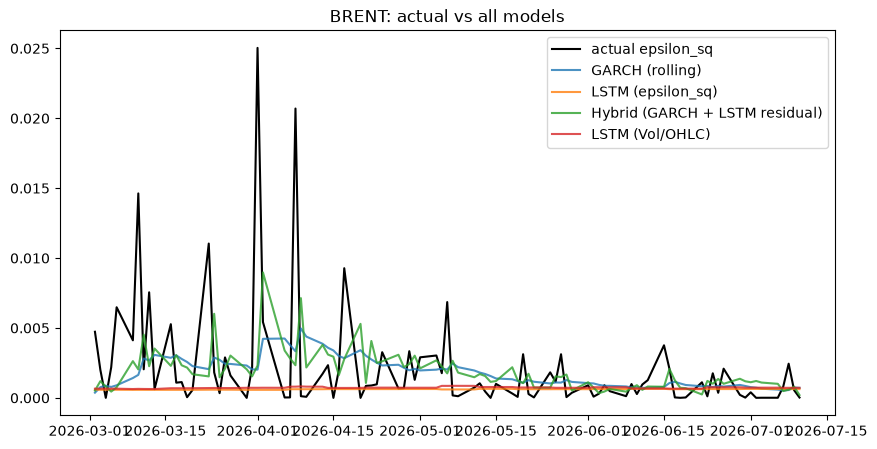

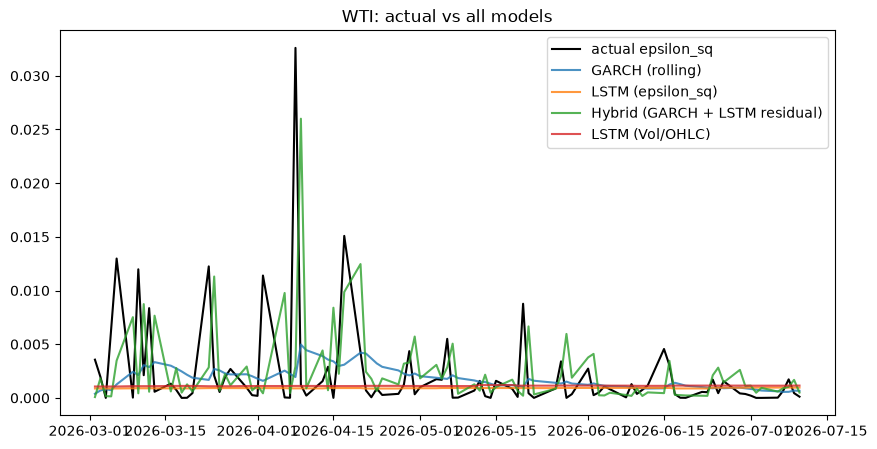

In [24]:
model_forecasts = {
    "GARCH (rolling)": rolling_1step_series,
    "LSTM (epsilon_sq)": rolling_lstm_series,
    "Hybrid (GARCH + LSTM residual)": hybrid_forecast,
    "LSTM (Vol/OHLC)": rolling_vol_preds,
}

for name in train_dict:
    plt.figure(figsize=(10, 5))
    plt.plot(epsilon_sq_test[name].index, epsilon_sq_test[name], label="actual epsilon_sq", color="black", linewidth=1.5)

    for model_name, forecasts in model_forecasts.items():
        series = forecasts[name]
        plt.plot(series.index, series, label=model_name, alpha=0.8)

    plt.legend()
    plt.title(f"{name}: actual vs all models")
    plt.show()

In [25]:
def qlike(actual, predicted):
    predicted = np.maximum(predicted, 1e-10)  # guard against zero/negative variance forecasts
    actual = np.maximum(actual, 1e-10)
    return np.mean(np.log(predicted) + actual / predicted)

# NOTE (code review, see accompanying report Section 6): "LSTM (Vol/OHLC)" is
# trained on the Rogers-Satchell/Yang-Zhang range-based volatility proxy
# (vol_test), not on epsilon_sq. Scoring it against epsilon_sq actuals compares
# two differently-scaled realized-volatility definitions. Each model is now
# evaluated against the actual series it was trained to predict.
actuals_by_model = {
    "GARCH (rolling)": epsilon_sq_test,
    "LSTM (epsilon_sq)": epsilon_sq_test,
    "Hybrid (GARCH + LSTM residual)": epsilon_sq_test,
    "LSTM (Vol/OHLC)": vol_test,
}

results = []

for name in train_dict:
    for model_name, forecasts in model_forecasts.items():
        actual = actuals_by_model[model_name][name]
        pred = forecasts[name].reindex(actual.index).dropna()
        common_actual = actual.loc[pred.index]

        rmse = np.sqrt(np.mean((common_actual - pred) ** 2))
        mae = np.mean(np.abs(common_actual - pred))
        ql = qlike(common_actual.values, pred.values)

        results.append({"series": name, "model": model_name, "RMSE": rmse, "MAE": mae, "QLIKE": ql})

results_df = pd.DataFrame(results)
print(results_df.sort_values(["series", "QLIKE"]))


  series                           model      RMSE       MAE     QLIKE
0  BRENT                 GARCH (rolling)  0.003935  0.002146 -5.104086
2  BRENT  Hybrid (GARCH + LSTM residual)  0.004032  0.002202 -5.103318
1  BRENT               LSTM (epsilon_sq)  0.004222  0.001915 -3.821767
3  BRENT                 LSTM (Vol/OHLC)  0.008289  0.002759 -2.534420
4    WTI                 GARCH (rolling)  0.004516  0.002359 -4.970250
5    WTI               LSTM (epsilon_sq)  0.004636  0.002023 -4.521774
7    WTI                 LSTM (Vol/OHLC)  0.007684  0.002490 -3.818861
6    WTI  Hybrid (GARCH + LSTM residual)  0.005544  0.002965 -3.429901
